In [ ]:
!pip install kaggle 

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/shailajakodag1/netflix-titlescsv")

Skipping, found downloaded files in "./netflix-titlescsv" (use force=True to force download)


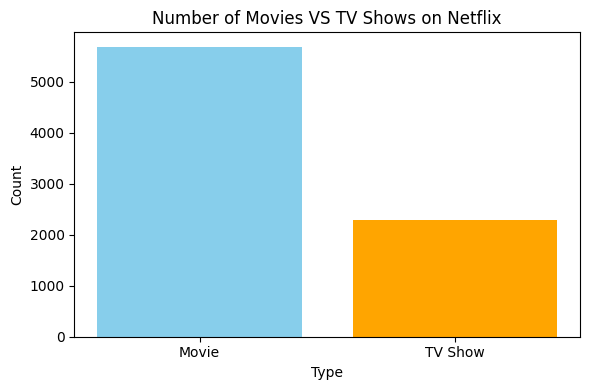

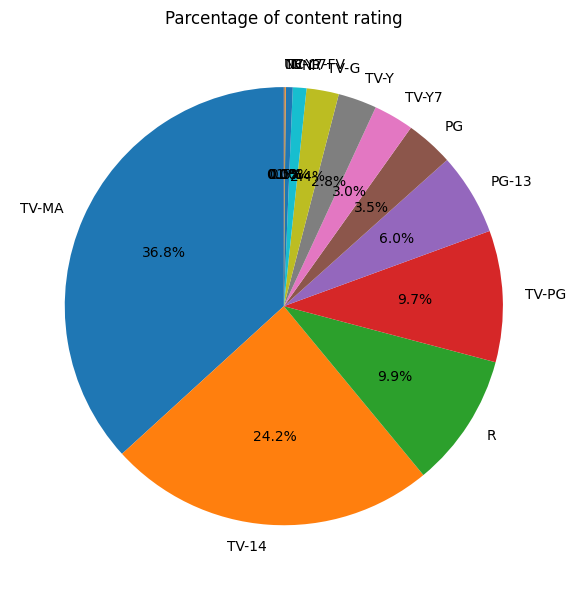

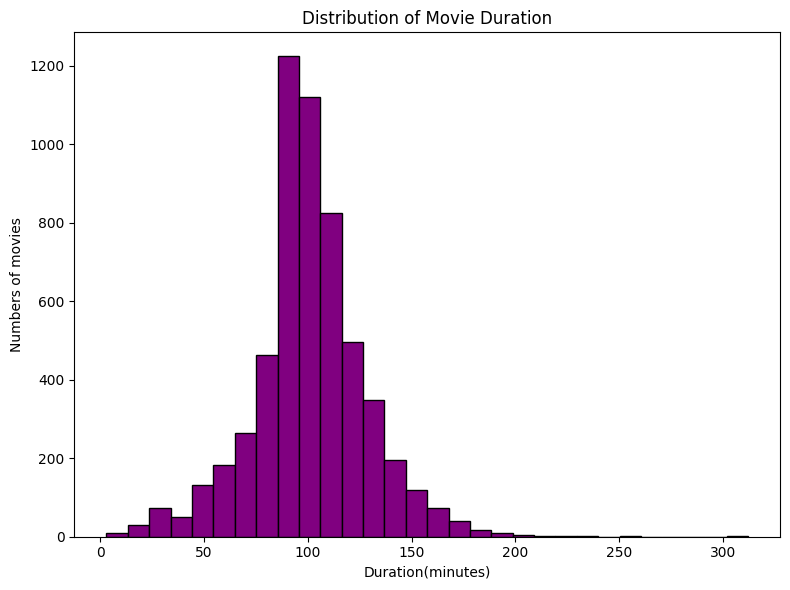

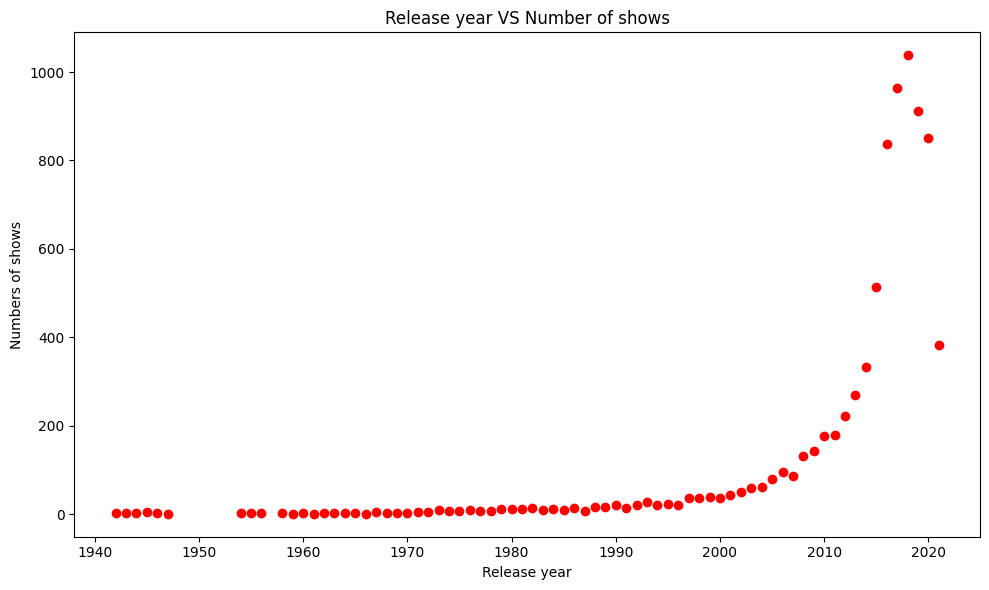

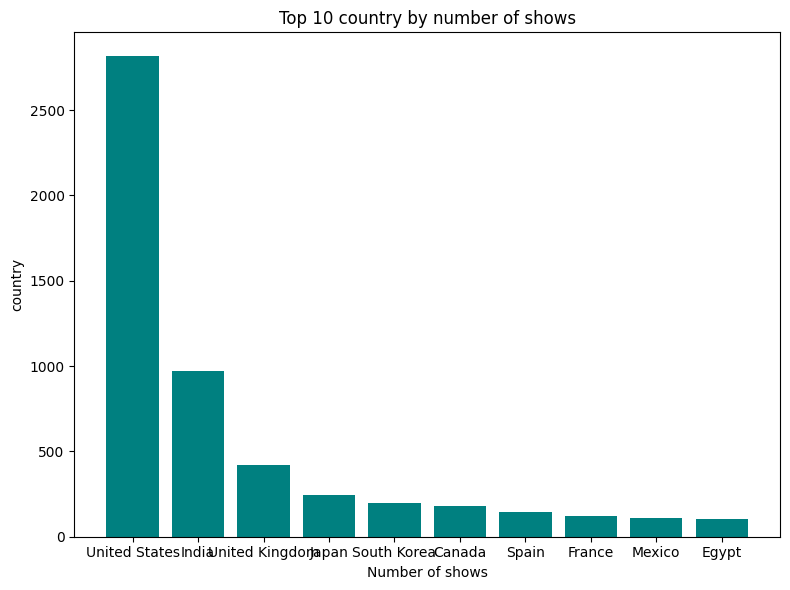

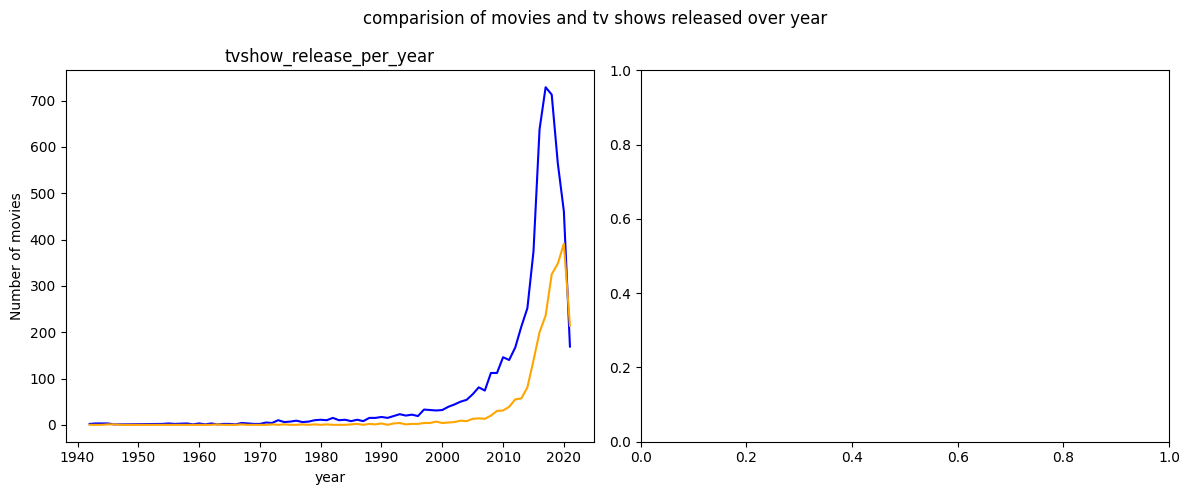

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/netflix-titlescsv/netflix_titles.csv")
#load data
df.head()

#clean data
df = df.dropna(subset =['type','release_year','rating','country','duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index,type_counts.values, color=['skyblue','orange'])
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Parcentage of content rating')
plt.tight_layout()
plt.savefig('contant_rating_parcentage_pie.png')
plt.show()

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration(minutes)')
plt.ylabel('Numbers of movies')
plt.tight_layout()
plt.savefig('movies_vs_histogram.png')
plt.show()

release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('Release year VS Number of shows')
plt.xlabel('Release year')
plt.ylabel('Numbers of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.bar(country_counts.index,country_counts.values, color='teal')
plt.title('Top 10 country by number of shows')
plt.xlabel('Number of shows')
plt.ylabel('country')
plt.tight_layout()
plt.savefig('top_10_countries.png')
plt.show()

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,5))
#first subplot:movies
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('movies_release_per_year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('Number of movies')

#second subplot:movies
ax[0].plot(content_by_year.index,content_by_year['TV Show'], color='orange')
ax[0].set_title('tvshow_release_per_year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('Number of movies')


fig.suptitle('comparision of movies and tv shows released over year')

plt.tight_layout()
plt.savefig('movies_tv_shows_comparision.png')
plt.show()